In [2]:
import sys
sys.path.append('/home/ldaddario')
import sigtab as s
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = scipy.io.loadmat('20260414-statusReformat-nonPWC-night-eq2.mat')

In [4]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'asig', 'astat', 'dpwr', 'dsig', 'pavg', 's', 'srq'])

In [24]:
dsig = data["dsig"]  # digital signal numbers
asig = data["asig"]
spectra = data["s"]  # 64x4096 array of spectra
srq = data["srq"]  # low res requantized spectra

In [35]:
asig = s.d2a(dsig)
antnames = s.d2name(dsig)[0, :]
sig = s.name2sig('LWA-058A')  #, for example.  Note case-sensitive spelling.  Returns None if arg is not a valid antenna name.
asig_ind = sig[0]
dsig_ind = sig[1]

In [37]:
np.shape(spectra)

(64, 4096)

In [36]:
antnames

array(['LWA-032A', 'LWA-032B', 'LWA-060A', 'LWA-060B', 'LWA-057A',
       'LWA-057B', 'LWA-059A', 'LWA-059B', 'LWA-058A', 'LWA-058B',
       'LWA-062A', 'LWA-062B', 'LWA-061A', 'LWA-061B', 'LWA-085A',
       'LWA-085B', 'LWA-087A', 'LWA-087B', 'LWA-089A', 'LWA-089B',
       'LWA-091A', 'LWA-091B', 'LWA-090A', 'LWA-090B', 'LWA-122A',
       'LWA-122B', 'LWA-121A', 'LWA-121B', 'LWA-120A', 'LWA-120B',
       'LWA-150A', 'LWA-150B', 'LWA-124A', 'LWA-124B', 'LWA-153A',
       'LWA-153B', 'LWA-155A', 'LWA-155B', 'LWA-154A', 'LWA-154B',
       'LWA-157A', 'LWA-157B', 'LWA-156A', 'LWA-156B', 'LWA-182A',
       'LWA-182B', 'LWA-185A', 'LWA-185B', 'LWA-184A', 'LWA-184B',
       'LWA-187A', 'LWA-187B', 'LWA-186A', 'LWA-186B', 'LWA-222A',
       'LWA-222B', 'LWA-183A', 'LWA-183B', 'LWA-221A', 'LWA-221B',
       'LWA-223A', 'LWA-223B', 'LWA-251A', 'LWA-251B'], dtype='<U8')

In [38]:
with open('LWA_spectra_14Apr26.npy', 'wb') as f:
    np.save(f, spectra)
    np.save(f, antnames)

In [25]:
use_spec_ind = np.where(dsig == dsig_ind)[1][0]
use_spec_ind = np.where(asig == asig_ind)[1][0]

(0.0, 1500.0)

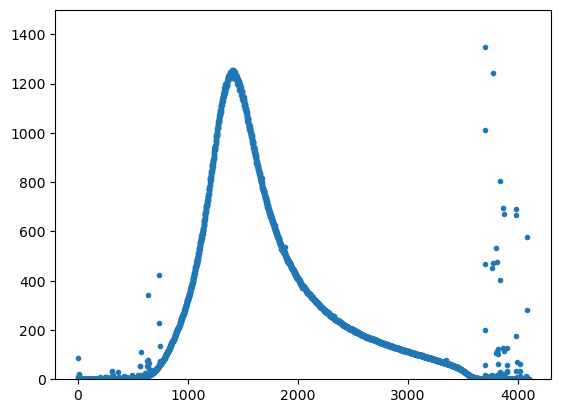

In [32]:
plt.plot((2**17)**2*spectra[use_spec_ind,:], ".")
plt.ylim([0,1500])